<a href="https://colab.research.google.com/github/DarrrkS/lab_ml_dl/blob/main/LR3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Подготовка данных

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from IPython.core.pylabtools import figsize
#ignore warnings
import warnings
warnings.filterwarnings('ignore')
figsize(40,20)

url = 'https://drive.google.com/u/0/uc?id=1-TzMGAKLjS9RrYXSBWCAD0zAk-gd1pab&export=download'
data = pd.read_csv(url)
y_column = 'quality'
X_columns = data.drop(y_column, axis=1).columns
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Все значения признаков ненулевые. Уберем дубликаты, так как они будут мешать в процессе обучения

In [11]:
print('Строк до: ', len(data))
data.drop_duplicates(keep='first', inplace=True)
print('Строк после: ',len(data))

Строк до:  1599
Строк после:  1359


In [12]:
data[y_column].describe()

count    1359.000000
mean        5.623252
std         0.823578
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

Почистим от коррелирующих признаков

In [13]:
data.drop(['citric acid', 'density', 'pH', 'total sulfur dioxide'], axis = 'columns', inplace=True)

## Распределение признаков

Рассмотрим возможные выбросы:

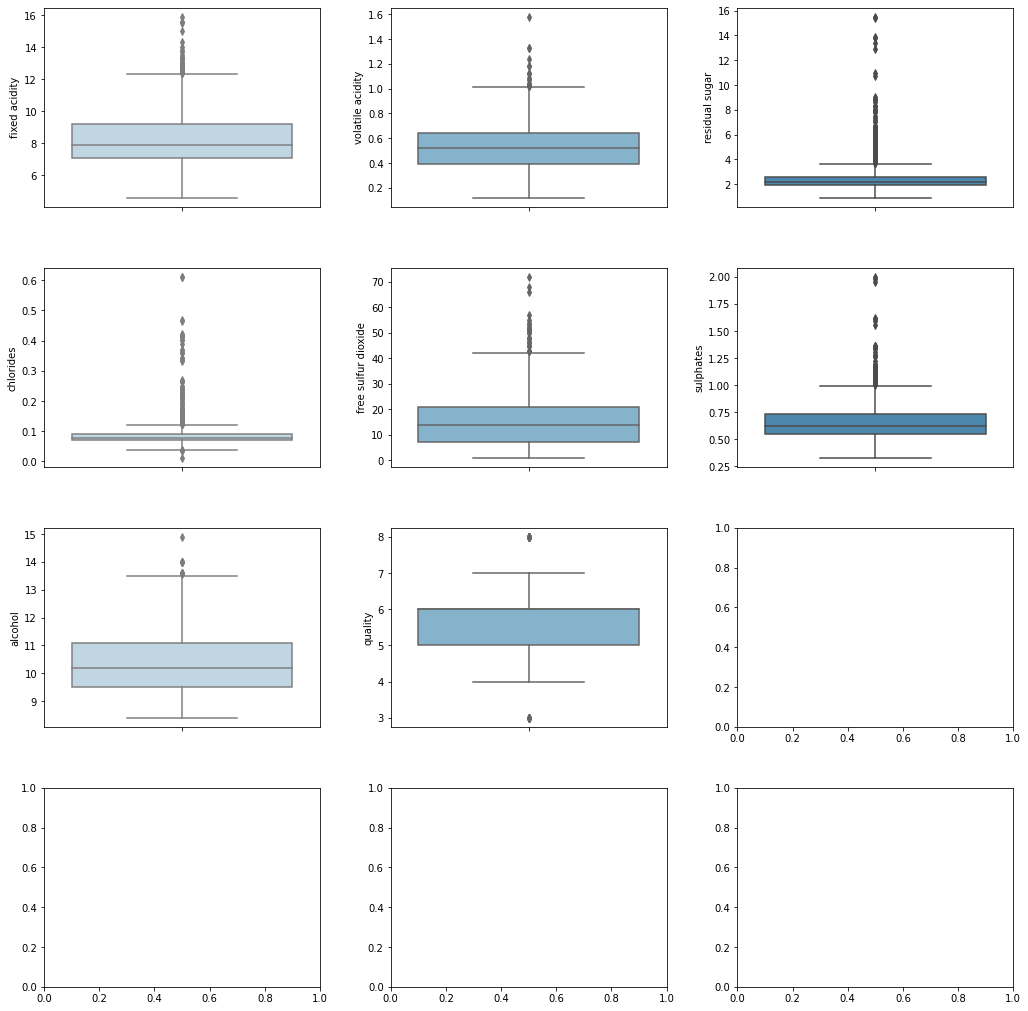

In [14]:
def plotBoxplot(data):
    fig, axes = plt.subplots(ncols=3, nrows=4, figsize=(15,15))
    fig.tight_layout(pad=4.0)

    col = 0
    row = 0
    colors = ['#bad9e9', '#7ab6d6', '#3c8abd']

    for i, column in enumerate(data.columns):
        sns.boxplot(y=column, data=data, ax=axes[row][col], color=colors[col])

        if (i + 1) % 3 == 0:
            row += 1
            col = 0
        else:
            col += 1
            
plotBoxplot(data)

Заменим целевую переменную на 0 - Bad и 1 - Good в соотвествии со спецификацией датасета (quality > 6.5 - Good)

In [15]:
data[y_column] = data[y_column].apply(lambda x: 1 if x > 6.5 else 0)
data.head()

,fixed acidity,volatile acidity,residual sugar,chlorides,free sulfur dioxide,sulphates,alcohol,quality
0,7.4,0.70,1.9,0.076,11.0,0.56,9.4,0
1,7.8,0.88,2.6,0.098,25.0,0.68,9.8,0
2,7.8,0.76,2.3,0.092,15.0,0.65,9.8,0
3,11.2,0.28,1.9,0.075,17.0,0.58,9.8,0
5,7.4,0.66,1.8,0.075,13.0,0.56,9.4,0


Избавимся от выбросов

In [16]:
quantile = 0.25
Q1 = data.quantile(quantile)
Q3 = data.quantile(1-quantile)
IQR = Q3 - Q1

print(IQR)

fixed acidity           2.100
volatile acidity        0.250
residual sugar          0.700
chlorides               0.021
free sulfur dioxide    14.000
sulphates               0.180
alcohol                 1.600
quality                 0.000
dtype: float64


In [17]:
# data = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]
# data.shape

Разделим данные на обучающие и тестовые

In [18]:
from sklearn.model_selection import train_test_split
X = data.drop([y_column], axis=1)
y = data[y_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=50)


Распределение классов в тренировочной выборке

Text(0.5, 1.0, 'Quality distribution')

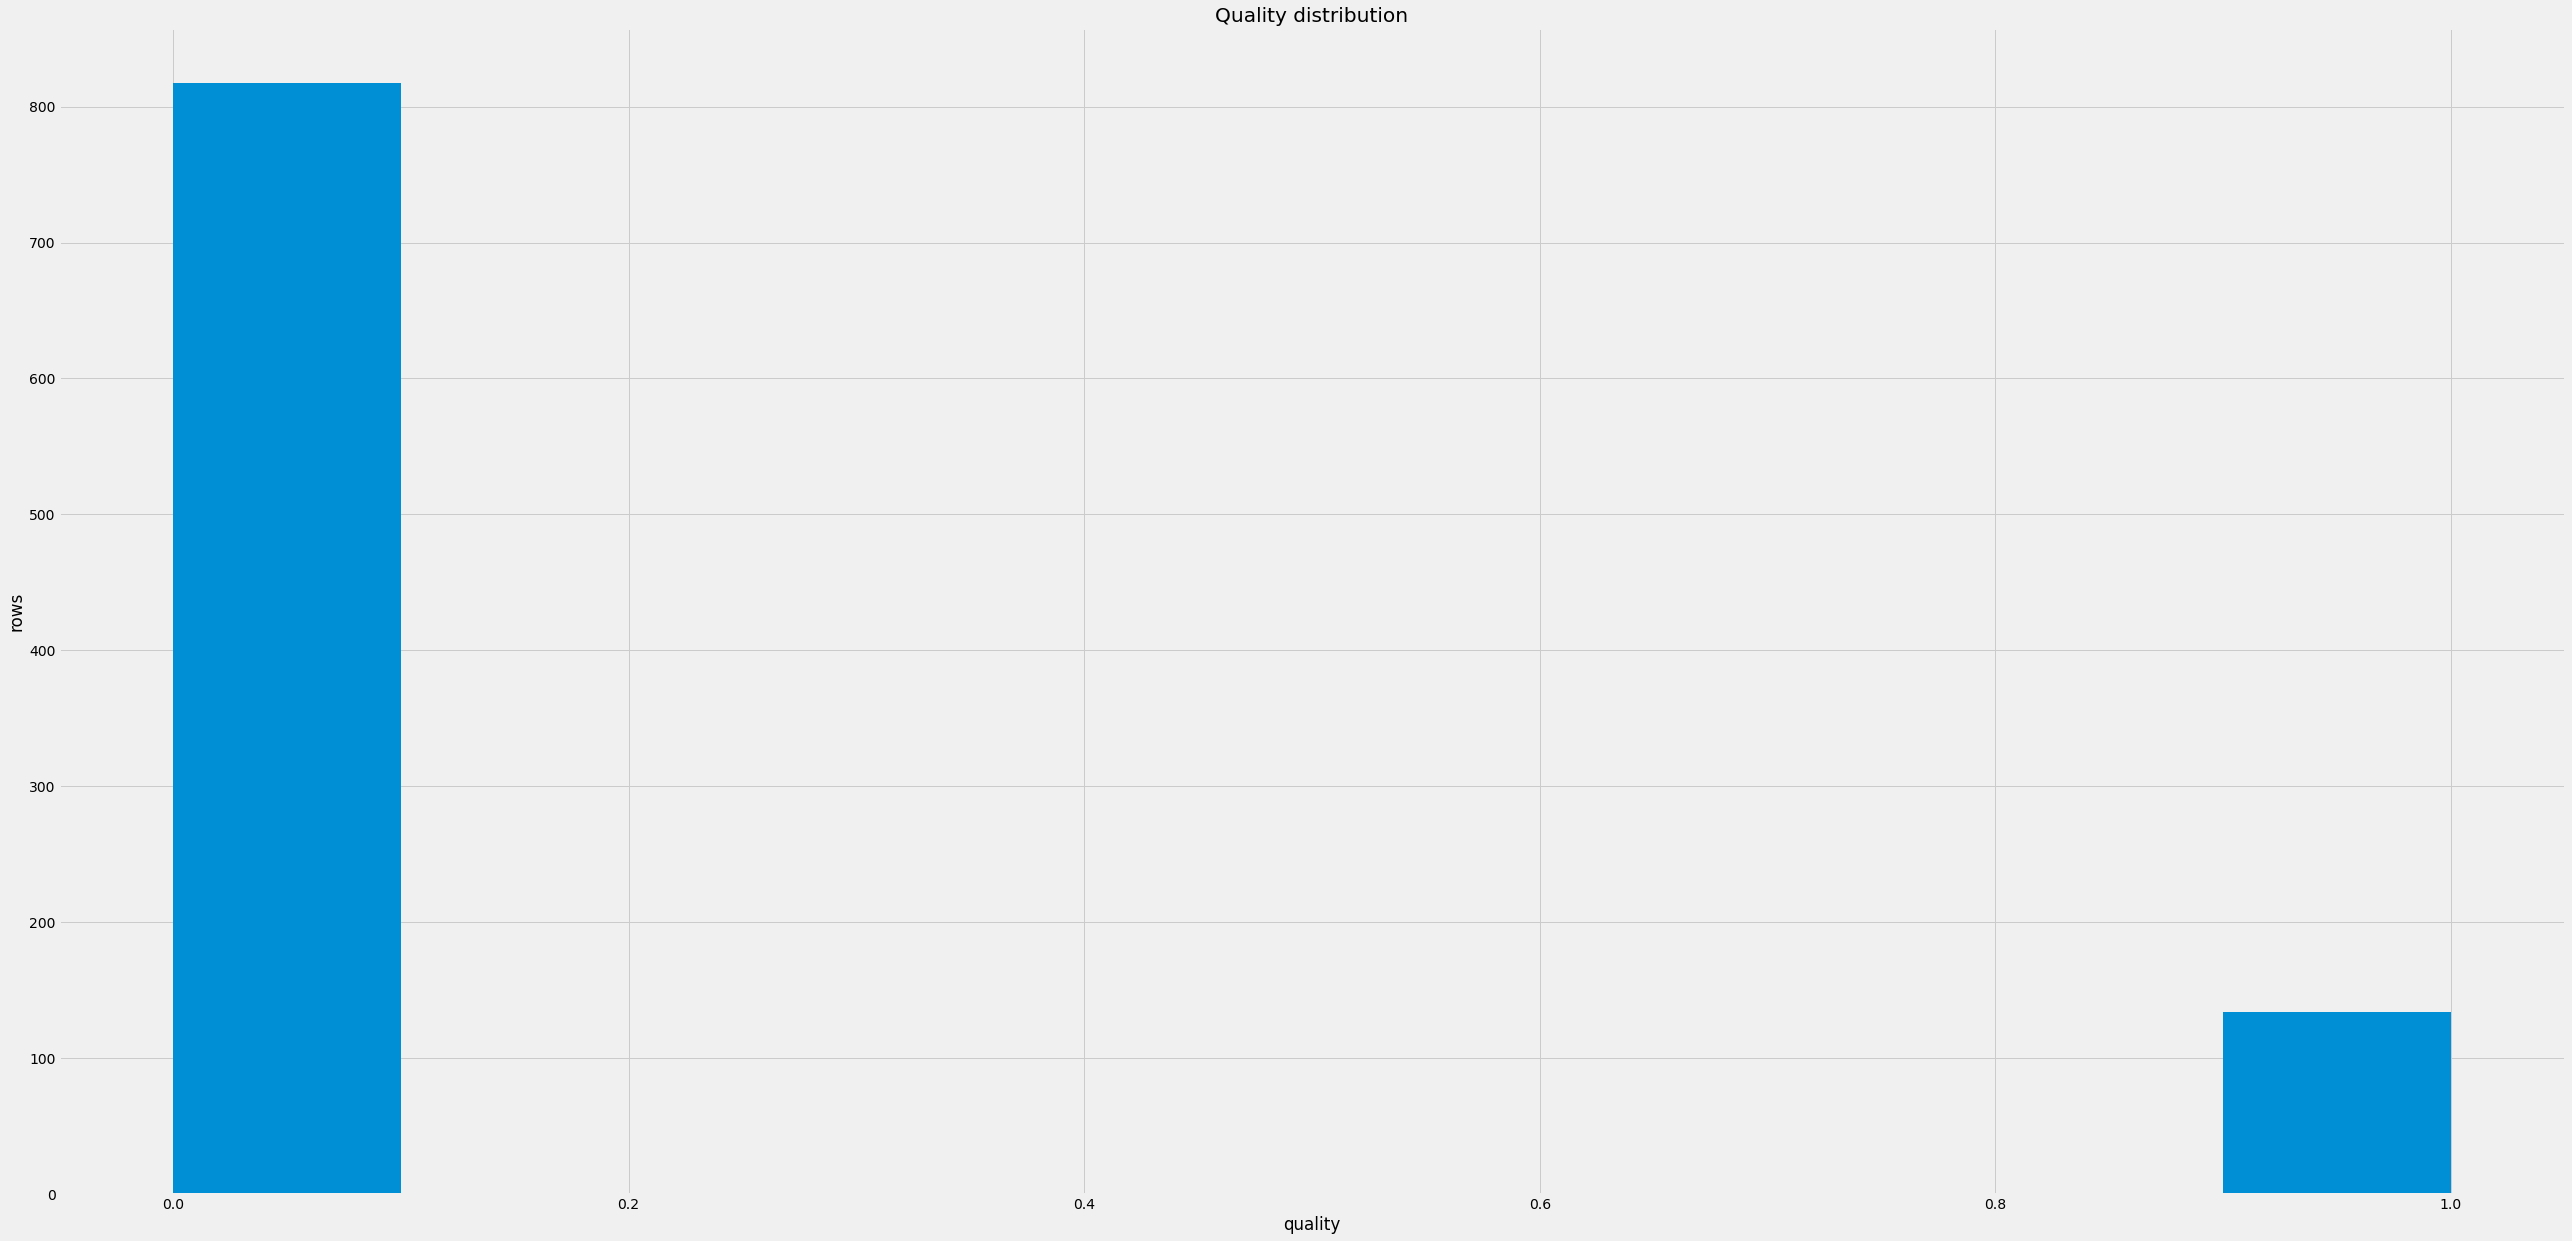

In [19]:
plt.style.use('fivethirtyeight')
plt.hist(y_train, bins=10)
plt.xlabel('quality')
plt.ylabel('rows')
plt.title('Quality distribution')

Функция подсчета метрик

In [20]:
def scores_results(y_train, y_test, y_pred_train, y_pred_test):
    #this function will provide us with accuracy and mse scores for training and test sets
    y_pred_train_round = np.round(y_pred_train)
    y_pred_test_round = np.round(y_pred_test)
    accuracy = [accuracy_score(y_train, y_pred_train_round), accuracy_score(y_test, y_pred_test_round)]
    mse_with_rounding = [mean_squared_error(y_train, y_pred_train_round), mean_squared_error(y_test, y_pred_test_round)]
    results = pd.DataFrame(list(zip(accuracy, mse_with_rounding)), columns = ['accuracy score', 'mse (after rounding)'], index = ['train', 'test'])
    return results

# Логистическая регрессия

In [21]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)


print(model.score(X_test, y_test))

0.8774509803921569


Данный результат получен при стандартных значениях параметров логистической регрессии. Найдем наилучший параметр C: 

In [22]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import plot_confusion_matrix, accuracy_score
kfold = KFold(n_splits=6, shuffle=True, random_state=10)
accuracy = []
C_list = [10**-5,10**-4,10**-3,10**-2,10**-1,10**0,10**1,10**2,10**3,10**4,10**5, 10**6, 10**7]
for C in C_list:
  clf = LogisticRegression(C=C, random_state=10)
  clf.fit(X_train,y_train)
  clf_pred = clf.predict(X_test)
  clf_score = accuracy_score(y_test, clf_pred)
  accuracy.append(clf_score)
  print('При C =',C,'точность равна',clf_score)
  # plot_confusion_matrix(clf, X_test, y_test)
index_max = np.argmax(accuracy)
print('\n')
print('Максимальная точность (score), равная',accuracy[index_max],'при С = ',C_list[index_max])

При C = 1e-05 точность равна 0.8774509803921569
При C = 0.0001 точность равна 0.8774509803921569
При C = 0.001 точность равна 0.8774509803921569
При C = 0.01 точность равна 0.875
При C = 0.1 точность равна 0.8848039215686274
При C = 1 точность равна 0.8774509803921569
При C = 10 точность равна 0.8799019607843137
При C = 100 точность равна 0.875
При C = 1000 точность равна 0.8725490196078431
При C = 10000 точность равна 0.8725490196078431
При C = 100000 точность равна 0.8725490196078431
При C = 1000000 точность равна 0.8725490196078431
При C = 10000000 точность равна 0.875


Максимальная точность (score), равная 0.8848039215686274 при С =  0.1


In [23]:
def log_reg(X_train, X_test, y_train, y_test):
    # basic linear regression
    from sklearn.linear_model import LinearRegression
    lm = LogisticRegression(C=index_max)
    lm.fit(X_train, y_train)
    y_pred_train = lm.predict(X_train)
    y_pred_test = lm.predict(X_test)
    global metrics_log #store this for a later comparison between different methods
    metrics_log = [accuracy_score(y_test, np.round(y_pred_test)), mean_squared_error(y_test, y_pred_test), r2_score(y_test, y_pred_test)]
    return scores_results(y_train, y_test, y_pred_train, y_pred_test)

log_reg(X_train, X_test, y_train, y_test)

,accuracy score,mse (after rounding)
train,0.880126,0.119874
test,0.879902,0.120098


# $L_1$-регуляризация


In [24]:
def lasso_reg(X_train_scaled, X_test_scaled, y_train, y_test):
    from sklearn.linear_model import LassoCV
    n_alphas = 5000
    alpha_vals = np.logspace(-6, 0, n_alphas)
    lr = LassoCV(alphas=alpha_vals, cv=10, random_state=0)
    lr.fit(X_train_scaled, y_train)
    y_pred_train = lr.predict(X_train_scaled)
    y_pred_test = lr.predict(X_test_scaled)
    metrics_lasso = [accuracy_score(y_test, np.round(y_pred_test)), mean_squared_error(y_test, y_pred_test), r2_score(y_test, y_pred_test)]
    return metrics_lasso

# $L_2$-регуляризация


In [25]:
def ridge_reg(X_train, X_test, y_train, y_test):
    from sklearn.linear_model import RidgeCV
    n_alphas = 100
    alpha_vals = np.logspace(-1, 3, n_alphas)
    rr = RidgeCV(alphas=alpha_vals, cv=10)
    rr.fit(X_train, y_train)
    y_pred_train = rr.predict(X_train)
    y_pred_test = rr.predict(X_test)
    metrics_ridge = [accuracy_score(y_test, np.round(y_pred_test)), mean_squared_error(y_test, y_pred_test), r2_score(y_test, y_pred_test)]
    return metrics_ridge

# Итоги

In [26]:
metrics_lasso = lasso_reg(X_train, X_test, y_train, y_test)
metrics_ridge = ridge_reg(X_train, X_test, y_train, y_test)
finalscores = pd.DataFrame(list(zip(metrics_log, metrics_lasso, metrics_ridge)), columns = ['LogReg', 'L1', 'L2'], index = ['acc','mse','r2'])
finalscores

,LogReg,L1,L2
acc,0.879902,0.884804,0.882353
mse,0.120098,0.089369,0.089316
r2,-0.116872,0.168895,0.169389
